# GNB
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB as GNB



----------------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])


## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

------------------

## GNB Model

הצגת צפי מודל על פי קרוס וולידציה 

In [6]:
gnb  = GNB()
cv_scores = cross_val_score(
    gnb,
    x_train, y_train,             
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("GNB CV fold accuracies:", np.round(cv_scores, 4))
print(f"GNB CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

GNB CV fold accuracies: [0.719  0.7248 0.7107 0.7495 0.7064]
GNB CV accuracy: 0.7221 ± 0.0151


בניית המודל

In [7]:
gnb.fit(x_train, y_train)

GaussianNB()

## Result

In [8]:
y_pred_gnb_train  = gnb.predict(x_train)
y_score_gnb_train = gnb.predict_proba(x_train)[:, 1]

In [9]:
train_acc_gnb = accuracy_score(y_train, y_pred_gnb_train)

אחוז דיוק

In [10]:
print("="*40)
print("BEST GNB — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_gnb*100:.2f}%")
print("="*40)

BEST GNB — TRAIN SET PERFORMANCE
Accuracy : 72.31%


הצגה גרפית של אחוזי דיוק בכל פולד

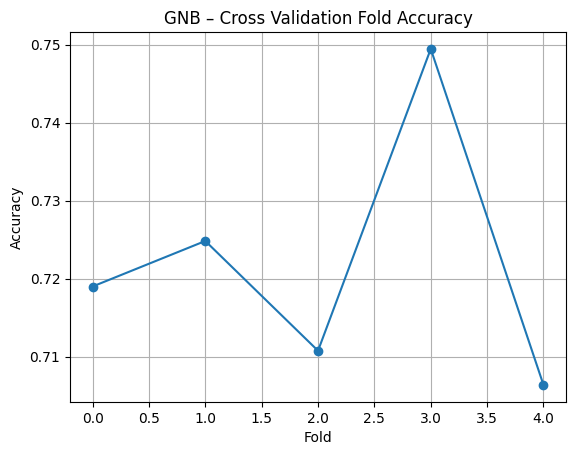

In [11]:
plt.plot(cv_scores, marker='o')
plt.title("GNB – Cross Validation Fold Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

Confusion Matrix

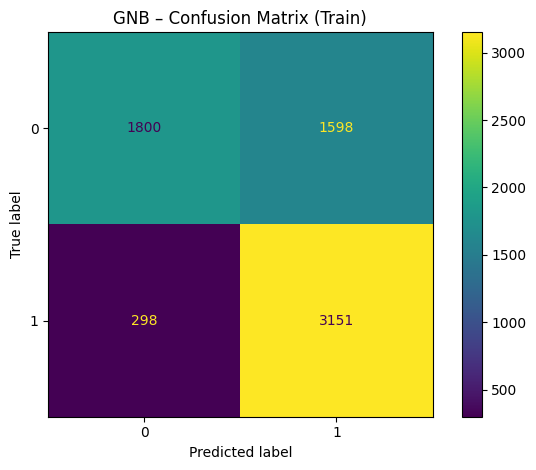

In [12]:
cm = confusion_matrix(y_train, y_pred_gnb_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("GNB – Confusion Matrix (Train)")
plt.tight_layout()
plt.show()

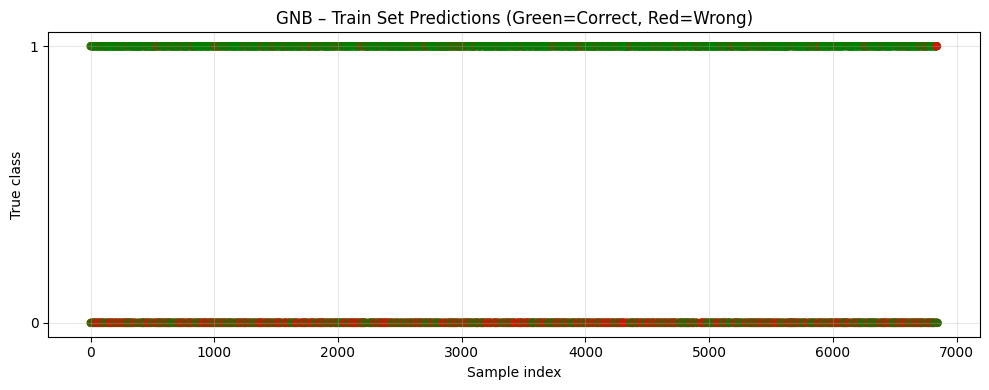

Accuracy: 72.31%
Errors: 1896 / 6847


In [13]:
correct = (y_pred_gnb_train == y_train)

# צבעים: ירוק לנכון, אדום לשגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_train)), y_train, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")  
plt.ylabel("True class")
plt.title("GNB – Train Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()      

print(f"Accuracy: {100*np.mean(correct):.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")